# 11. Trees and Forests

In this exercise, I took real data on the location decisions of European soccer players, and attempted to predict their country of residence using decision tree and random forest clafficiation methods. This data comes from

*Kleven, Henrik Jacobsen, Camille Landais, and Emmanuel Saez, “Taxation and international migration of superstars: Evidence from the European football market,”* American Economic Review, *2013, 103 (5), 1892–1924.*

and was used to study where elite European soccer (football, fútbol, etc.) players choose to live in work, based on both their career opportunities, their nation of origin, and also their tax incentives with varying tax rates across European countries. I used it to construct classifier models that will predict what country players play in given their ability and incentives.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split

Unfortunately, the data I used has been lost when I got a new computer, but I still have the code:

In [2]:
# Import the soccer data to a Pandas dataframe
path='../data/futbol.csv'
df=pd.read_csv(path)

FileNotFoundError: [Errno 2] No such file or directory: '../data/futbol.csv'

In [3]:
# Take a look at a few rows of the data
df.head()

,player_id,playquality4,experience,age,taxrate_domestic,taxrate_foreign,nation,residence,nation_2,nation_3,...,nation_5,nation_6,nation_7,nation_8,nation_9,nation_10,nation_11,nation_12,nation_13,nation_14
0,2,3,11,29,55.183338,60.192574,4,4,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,3,5,22,59.264709,59.878624,6,6,0,0,...,0,1,0,0,0,0,0,0,0,0
2,4,3,5,21,55.183338,60.192574,4,4,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,2,21,36.399998,59.847916,9,9,0,0,...,0,0,0,0,1,0,0,0,0,0
4,7,0,0,18,55.183338,60.192574,4,4,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.describe()

,player_id,playquality4,experience,age,taxrate_domestic,taxrate_foreign,nation,residence,nation_2,nation_3,...,nation_5,nation_6,nation_7,nation_8,nation_9,nation_10,nation_11,nation_12,nation_13,nation_14
count,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,...,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000
mean,3351.764639,1.500342,6.396218,24.980178,51.757144,59.835406,7.379130,7.272272,0.067669,0.066530,...,0.104124,0.076327,0.050809,0.085441,0.078833,0.061290,0.058100,0.092504,0.081568,0.034176
std,1907.265437,1.117856,4.955637,5.237593,11.796130,0.507618,3.819453,3.799788,0.251206,0.249235,...,0.305456,0.265551,0.219632,0.279568,0.269509,0.239888,0.233959,0.289769,0.273736,0.181703
min,2.000000,0.000000,0.000000,15.000000,32.231407,58.764355,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1718.000000,1.000000,2.000000,21.000000,44.800003,59.701275,4.000000,4.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3366.000000,2.000000,6.000000,24.000000,53.416668,59.847916,7.000000,7.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4999.000000,2.000000,10.000000,29.000000,59.264709,60.192574,11.000000,10.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6634.000000,3.000000,26.000000,45.000000,73.750183,60.623615,14.000000,14.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.columns

Index(['player_id', 'playquality4', 'experience', 'age', 'taxrate_domestic',
       'taxrate_foreign', 'nation', 'residence', 'nation_2', 'nation_3',
       'nation_4', 'nation_5', 'nation_6', 'nation_7', 'nation_8', 'nation_9',
       'nation_10', 'nation_11', 'nation_12', 'nation_13', 'nation_14'],
      dtype='object')

These variables correspond to:
- player_id: ID nubmer for individual soccer player
- playquality4: 1-4 ranking of the player's estimated skill at the sport. 
- experience: years playing professionally
- age: age
- taxrate_domestic: The player's tax rate if they play in their home country
- taxrate_foreign: The player's average tax rate if they play abroad
- nation: 1-11 indicator, categorical, for the player's country of origin
- residence: 1-11 indicator, categorical, for the coutnry where the player lives and pays taxes
- nation_XX: One-hot dummy variables for particular values of "nation"

In [6]:
# Define a dataframe that labels those country codes.
country_names=pd.DataFrame([[1, 'Austria'],
                        [2, 'Belgium'],
                        [3, 'Denmark'],
                        [4, 'England'],
                        [5, 'France'],
                        [6, 'Germany'],
                        [7, 'Greece'],
                        [8, 'Italy'],
                        [9, 'Netherlands'],
                        [10, 'Norway'],
                        [11, 'Portugal'],
                        [12, 'Spain'],
                        [13, 'Sweden'],
                        [14, 'Switzerland']], columns=['country_number','country_name'])

In [7]:
country_names

,country_number,country_name
0,1,Austria
1,2,Belgium
2,3,Denmark
3,4,England
4,5,France
5,6,Germany
6,7,Greece
7,8,Italy
8,9,Netherlands
9,10,Norway


## Prepare the data for ML

Create a dataframe `y` with the target variable, country of residence + another dataframe `x` with the features: player quality, experience, age, tax rates (domestic and foreign).

In [8]:
# Define the testing and training subsets of the data
y=df['residence']

# Uncomment this version for congruence to the mlogit example
X=df[['playquality4','experience','age','taxrate_domestic','taxrate_foreign']]

# Uncomment this version to add dummies by nation of origin if you like
#X=df[['playquality4','experience','age','taxrate_domestic','taxrate_foreign','nation_2','nation_3','nation_4','nation_5','nation_6','nation_7','nation_8','nation_9','nation_10','nation_11','nation_12','nation_13','nation_14']]

Use train_test_split to divide `y` and `X` into training and testing samples. Put 30% of the data into the testing set and 70% into the training set.

In [9]:
# Split data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Let's look at our divided sample:
X_train

,playquality4,experience,age,taxrate_domestic,taxrate_foreign
532,2,13,35,55.183338,60.192574
3756,3,5,22,34.482758,60.524982
2510,2,5,25,53.416668,60.328472
3395,0,0,18,61.240311,59.726654
3257,2,10,27,44.800003,59.066368
...,...,...,...,...,...
3444,3,7,25,65.383293,59.407963
466,3,7,27,34.482758,60.524982
3092,1,8,28,44.800003,59.066368
3772,2,17,36,58.150356,59.763138


In [11]:
X_test

,playquality4,experience,age,taxrate_domestic,taxrate_foreign
4239,0,8,26,73.750183,58.764355
3024,2,4,22,34.482758,60.524982
2607,1,7,25,65.383293,59.407963
912,0,12,30,73.750183,58.764355
877,3,13,31,34.482758,60.524982
...,...,...,...,...,...
1937,1,15,34,58.150356,59.763138
4319,0,4,20,56.084793,60.123230
2390,1,4,21,52.360249,59.737633
948,1,14,30,32.231407,59.701275


In [12]:
y_train

532      4
3756    12
2510     8
3395     1
3257     9
        ..
3444    11
466     12
3092     3
3772    10
860      4
Name: residence, Length: 3072, dtype: int64

In [13]:
y_test

4239    13
3024    12
2607    11
912     13
877     12
        ..
1937    10
4319    14
2390     5
948      2
1374     4
Name: residence, Length: 1317, dtype: int64

## Predict residence using a classification decision tree

Fill in the blanks to define a classifier decision tree object.

In [14]:
# Define a decision tree classifier
# Instead of setting up a pruning process, take the
# quicker but cruder route and limit the number of splits 
# using max_leaf_nodes (e.g. max_leaf_nodes=8) so the tree
# doesn't grow indefinitely

clf=tree.DecisionTreeClassifier(random_state=0, 
                                max_leaf_nodes=10,
                                max_depth=4
                               )

### Train the tree

Use the training data to fit the decision tree.

In [15]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10, random_state=0)

Now, fill in the blanks to visualize the decision tree simply.

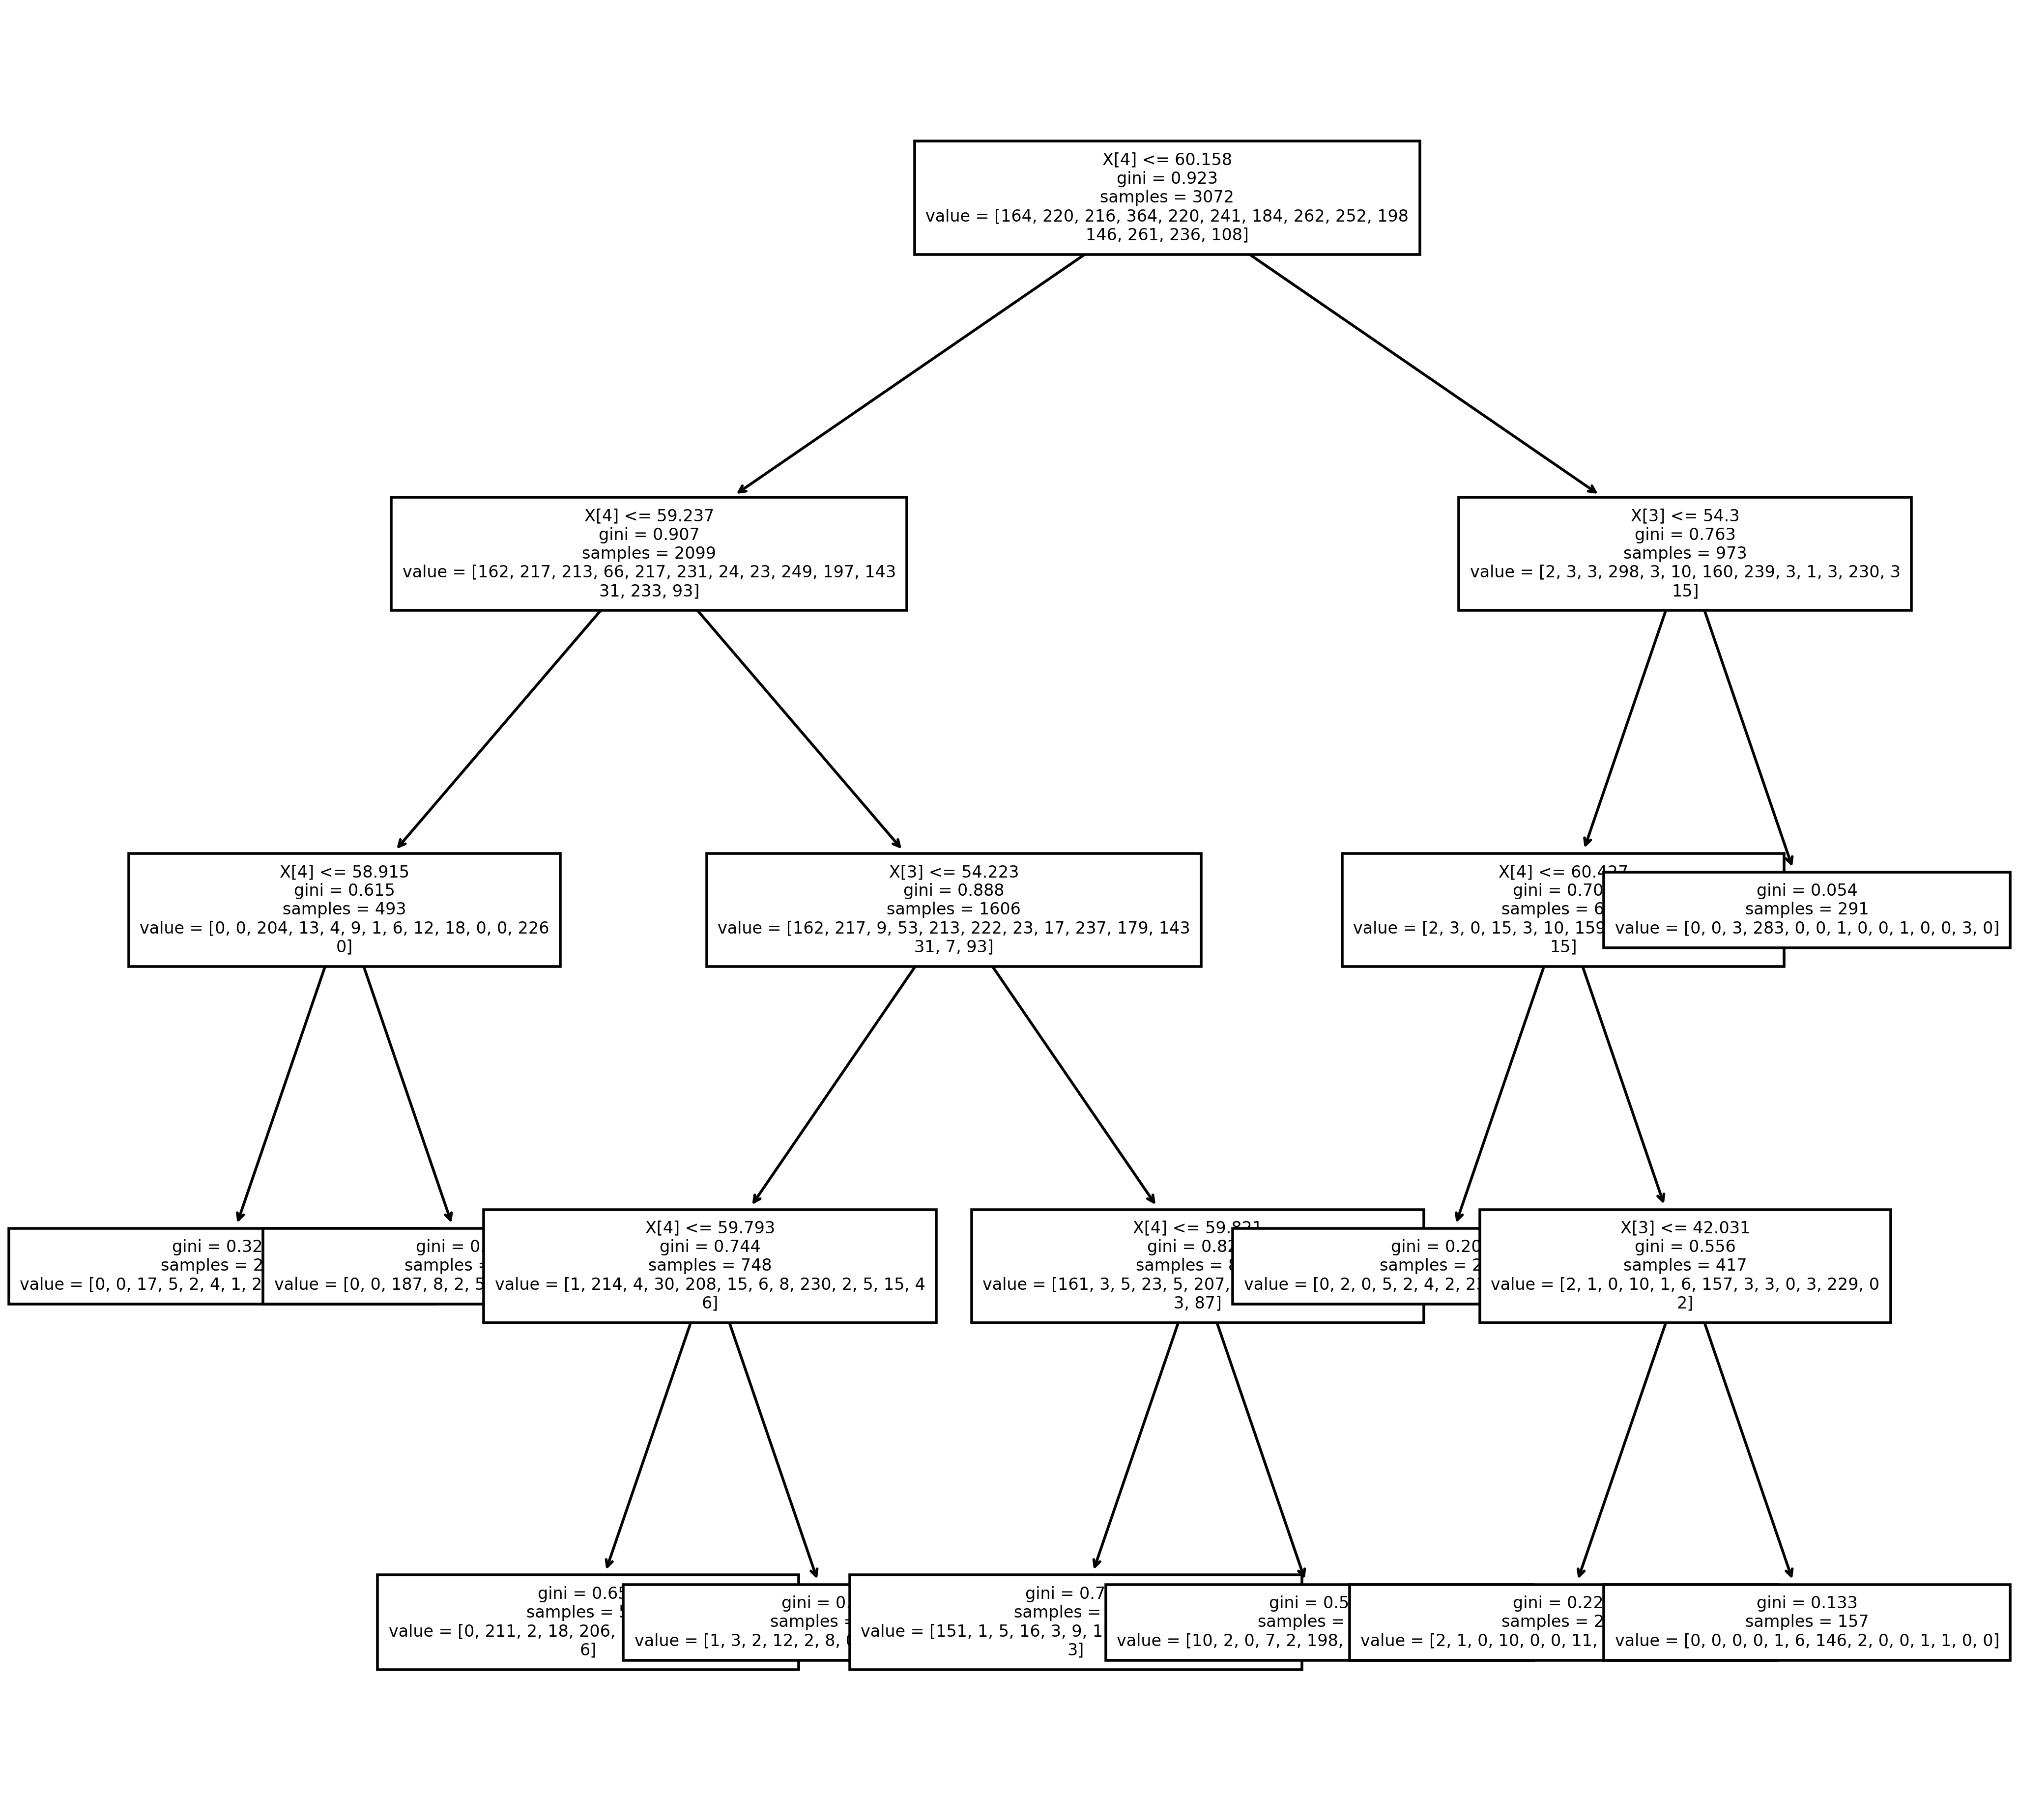

In [16]:
# Observe Tree
plt.figure(figsize=[12,12],dpi=200)
tree.plot_tree(clf, fontsize=6)
plt.show()

Make more sophisticated and readable visualization using graphviz

In [17]:
# For creating a tree in graphviz, need a dict with index starting at 0
#country_names['country_index']=country_names['country_number']-1
country_labels=country_names['country_name'].to_dict()
country_labels

{0: 'Austria',
 1: 'Belgium',
 2: 'Denmark',
 3: 'England',
 4: 'France',
 5: 'Germany',
 6: 'Greece',
 7: 'Italy',
 8: 'Netherlands',
 9: 'Norway',
 10: 'Portugal',
 11: 'Spain',
 12: 'Sweden',
 13: 'Switzerland'}

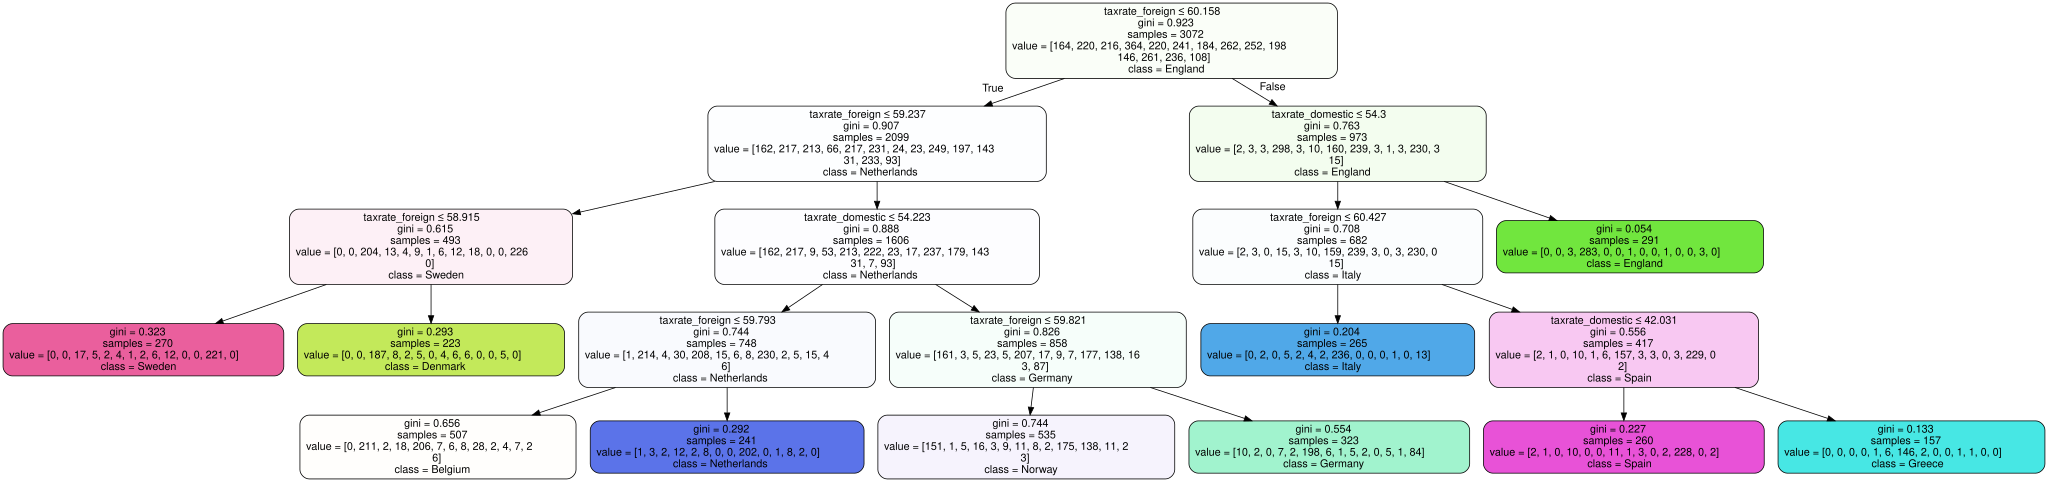

In [18]:
import graphviz 
graph_data = tree.export_graphviz(clf, 
                        feature_names=X_train.columns, 
                        class_names=country_labels,
                        out_file=None, 
                        filled=True, 
                        rounded=True,  
                        special_characters=True) 
graph = graphviz.Source(graph_data) 
graph

### Check the fit of the tree 

Generate predictions for observations in the testing dataset. Store them in a dataframe with the column name "prediction".

In [19]:
y_predictions=pd.DataFrame(clf.predict(X_test)).rename(columns={0: "prediction"})

In [20]:
y_predictions

,prediction
0,13
1,12
2,10
3,13
4,12
...,...
1312,10
1313,6
1314,2
1315,2


This code will create a version of the testing target with the rows indexed by their random order, not by their original index values. This will make it easier to compare actual outcomes to predicted outcomes generated by the tree.

In [21]:
y_check=y_test.reset_index().drop('index', axis=1)

In [22]:
y_check

,residence
0,13
1,12
2,11
3,13
4,12
...,...
1312,10
1313,14
1314,5
1315,2


Use `.concat` to combine the actual countries of residence for the testing data and the model's predicitons in a single dataframe. Then generate a Boolean column equal to True if the model guessed correctly, and False if it didn't. 

In [23]:
# Create a boolean column for whether the tree predicted correctly
y_compare=(pd.concat([y_check,y_predictions], axis=1))
          
y_compare['correct_prediction']=(y_compare['prediction']==y_compare['residence'])

In [24]:
y_compare['correct_prediction'].value_counts()

True     877
False    440
Name: correct_prediction, dtype: int64

This was a manual way of looking at the distribuiton of correct and incorrect predictions. Use `sklearn`'s accuracy score calculator to find the percentage correct.

In [25]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_compare['prediction'],y_compare['residence']))

Accuracy: 0.665907365223994


## Random Forest

Build another classifier, using a random forest. 

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
# Define a random forest classifier
rfc=RandomForestClassifier(random_state=0, 
                            max_samples=100,
                            max_features='sqrt',
                            n_estimators=1_000,
                            max_leaf_nodes=10,
                            max_depth=4
                          )

Fit the forest to the training data.

In [28]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, max_leaf_nodes=10, max_samples=100,
                       n_estimators=1000, random_state=0)

Use forest to predict the country of residence for players in the testing data.

In [29]:
y_compare['rf_prediction']=rfc.predict(X_test)

Compute accuracy scores for tree and forest out of sample. 

In [30]:
print("Tree Accuracy:",metrics.accuracy_score(y_compare['prediction'],y_compare['residence']))
print("Forest Accuracy:",metrics.accuracy_score(y_compare['rf_prediction'],y_compare['residence']))

Tree Accuracy: 0.665907365223994
Forest Accuracy: 0.8595292331055429


Calculate the % of the time you would be correct if you just guessed the most common country for all observations in the dataframe.

In [31]:
# Count the number of observations (rows) in the dataframe
total_observations=(df.shape[0])

# Count the number of observations in the most common category
most_common_category_observations=df['residence'].value_counts().iloc[0]

In [32]:
print(most_common_category_observations/total_observations)

0.1139211665527455



*Guessing the most common country every time would only give you aoubt an 11% success rate. The tree does much better than that, and the random forest does significanlty better than our tree. It looks like tax rates are important for understanding the location decisions of elite soccer players.*